# HW10-11: Computer Vision with PyTorch
## Part A: Image Classification (STL-10)
## Part B: Semantic Segmentation (OxfordIIITPet)

## 1. Импорты, seed и устройство

In [1]:
import sys
print('PYTHON EXECUTABLE:', sys.executable)
import subprocess
for pkg in ['numpy', 'matplotlib', 'torch', 'torchvision']:
    out = subprocess.check_output([sys.executable, '-m', 'pip', 'show', pkg], text=True)
    version = [line for line in out.splitlines() if line.startswith('Version:')]
    location = [line for line in out.splitlines() if line.startswith('Location:')]
    print(pkg, version[0] if version else 'Version: N/A', location[0] if location else 'Location: N/A')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from pathlib import Path
import warnings
from PIL import Image
from scipy import ndimage
warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}')
print(f'Torchvision: {torchvision.__version__}')

PYTHON EXECUTABLE: c:\Users\artem\anaconda3\python.exe
numpy Version: 1.26.4 Location: c:\Users\artem\anaconda3\Lib\site-packages
matplotlib Version: 3.9.2 Location: c:\Users\artem\anaconda3\Lib\site-packages
torch Version: 2.11.0 Location: c:\Users\artem\anaconda3\Lib\site-packages
torchvision Version: 0.26.0 Location: c:\Users\artem\anaconda3\Lib\site-packages
PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu


In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cpu


## 2. Загрузка данных для части A (STL-10)

In [3]:
data_dir = Path('./data')
data_dir.mkdir(exist_ok=True)
artifacts_dir = Path('./artifacts')
figures_dir = artifacts_dir / 'figures'
artifacts_dir.mkdir(exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

train_dataset = datasets.STL10(root=str(data_dir), split='train', download=True, transform=None)
test_dataset = datasets.STL10(root=str(data_dir), split='test', download=True, transform=None)

print(f'Train size: {len(train_dataset)}, Test size: {len(test_dataset)}, Classes: {len(train_dataset.classes)}')
print(f'Classes: {train_dataset.classes}')

100%|██████████| 2.64G/2.64G [09:46<00:00, 4.50MB/s] 


Train size: 5000, Test size: 8000, Classes: 10
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [4]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_split, val_split = random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

print(f'Train: {len(train_split)}, Val: {len(val_split)}, Test: {len(test_dataset)}')

Train: 4000, Val: 1000, Test: 8000


## 3. Трансформации и аугментации

In [5]:
IMG_SIZE = 96

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

augmented_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

resnet_transform = basic_transform
print('Transforms created')

Transforms created


## 4. DataLoaders

In [6]:
class DatasetWithTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

train_data_basic = DatasetWithTransform(train_split, basic_transform)
val_data = DatasetWithTransform(val_split, basic_transform)
test_data = DatasetWithTransform(test_dataset, basic_transform)
train_data_aug = DatasetWithTransform(train_split, augmented_transform)

BATCH_SIZE = 32
train_loader_basic = DataLoader(train_data_basic, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
train_loader_aug = DataLoader(train_data_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'DataLoaders created')

DataLoaders created


## 5. Sanity-check

Batch shape: torch.Size([32, 3, 96, 96]), Labels: torch.Size([32])


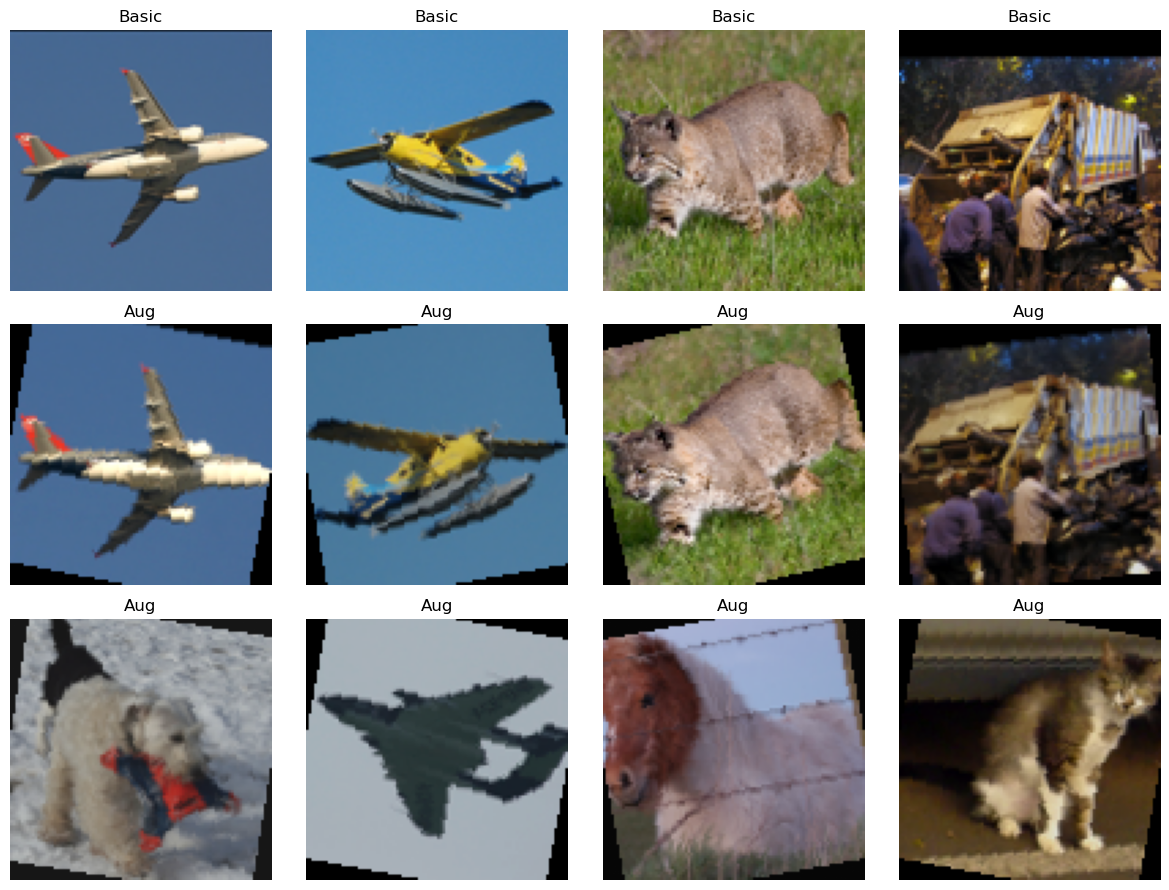

In [7]:
x, y = next(iter(train_loader_basic))
print(f'Batch shape: {x.shape}, Labels: {y.shape}')

def denormalize(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    return torch.clamp(t * std + mean, 0, 1)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i in range(4):
    img, label = train_data_basic[i]
    axes[0, i].imshow(denormalize(img).permute(1, 2, 0).numpy())
    axes[0, i].set_title('Basic')
    axes[0, i].axis('off')
for i in range(4):
    img, label = train_data_aug[i]
    axes[1, i].imshow(denormalize(img).permute(1, 2, 0).numpy())
    axes[1, i].set_title('Aug')
    axes[1, i].axis('off')
for i in range(4, 8):
    img, label = train_data_aug[i]
    axes[2, i-4].imshow(denormalize(img).permute(1, 2, 0).numpy())
    axes[2, i-4].set_title('Aug')
    axes[2, i-4].axis('off')
plt.tight_layout()
plt.savefig('./artifacts/figures/augmentations_preview.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Training functions

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = logits.max(1)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)
    return total_loss / len(loader), total_correct / total_samples

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item()
            _, preds = logits.max(1)
            total_correct += (preds == y).sum().item()
            total_samples += y.size(0)
    return total_loss / len(loader), total_correct / total_samples

## 7-10. CNN Experiments C1-C4

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 12 * 12, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

criterion = nn.CrossEntropyLoss()
NUM_EPOCHS = 20
results_a = {}

In [10]:
for exp, (loader, lr_val) in [('C1', (train_loader_basic, 0.01)), ('C2', (train_loader_aug, 0.01))]:
    print(f'Training {exp}')
    torch.manual_seed(SEED)
    model = SimpleCNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr_val, momentum=0.9)
    best_acc, best_state = 0, None
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        hist['train_loss'].append(train_loss)
        hist['train_acc'].append(train_acc)
        hist['val_loss'].append(val_loss)
        hist['val_acc'].append(val_acc)
        if val_acc > best_acc:
            best_acc, best_state = val_acc, model.state_dict().copy()
        if (epoch+1) % 5 == 0:
            print(f'  Epoch {epoch+1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}')
    
    results_a[exp] = {'best_val_acc': best_acc, 'model': best_state, 'model_obj': model, 'history': hist}
    print(f'{exp} best: {best_acc:.4f}')

Training C1
  Epoch 5: train_acc=0.5760, val_acc=0.5420
  Epoch 10: train_acc=0.8468, val_acc=0.5490
  Epoch 15: train_acc=0.9410, val_acc=0.5830
  Epoch 20: train_acc=0.9630, val_acc=0.5620
C1 best: 0.5930
Training C2
  Epoch 5: train_acc=0.4290, val_acc=0.4990
  Epoch 10: train_acc=0.5395, val_acc=0.5750
  Epoch 15: train_acc=0.5927, val_acc=0.5630
  Epoch 20: train_acc=0.6610, val_acc=0.6200
C2 best: 0.6200


In [11]:
for exp in ['C3', 'C4']:
    print(f'Training {exp}')
    torch.manual_seed(SEED)
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(device)
    
    if exp == 'C3':
        for param in model.parameters():
            param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, 10).to(device)
        optimizer = optim.SGD(model.fc.parameters(), lr=0.01, momentum=0.9)
    else:  # C4
        for param in model.layer1.parameters():
            param.requires_grad = False
        for param in model.layer2.parameters():
            param.requires_grad = False
        for param in model.layer3.parameters():
            param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, 10).to(device)
        finetune_params = list(model.layer4.parameters()) + list(model.fc.parameters())
        optimizer = optim.SGD(finetune_params, lr=0.001, momentum=0.9)
    
    best_acc, best_state = 0, None
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader_basic, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        hist['train_loss'].append(train_loss)
        hist['train_acc'].append(train_acc)
        hist['val_loss'].append(val_loss)
        hist['val_acc'].append(val_acc)
        if val_acc > best_acc:
            best_acc, best_state = val_acc, model.state_dict().copy()
        if (epoch+1) % 5 == 0:
            print(f'  Epoch {epoch+1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}')
    
    results_a[exp] = {'best_val_acc': best_acc, 'model': best_state, 'model_obj': model, 'history': hist}
    print(f'{exp} best: {best_acc:.4f}')

Training C3
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\artem/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:06<00:00, 7.58MB/s]


  Epoch 5: train_acc=0.8007, val_acc=0.7730
  Epoch 10: train_acc=0.8297, val_acc=0.7630
  Epoch 15: train_acc=0.8438, val_acc=0.7610
  Epoch 20: train_acc=0.8448, val_acc=0.7330
C3 best: 0.7740
Training C4
  Epoch 5: train_acc=0.9705, val_acc=0.8570
  Epoch 10: train_acc=0.9958, val_acc=0.8590
  Epoch 15: train_acc=0.9965, val_acc=0.8640
  Epoch 20: train_acc=0.9985, val_acc=0.8680
C4 best: 0.8680


## 11. Comparison and best model

Results: [('C1', '0.5930'), ('C2', '0.6200'), ('C3', '0.7740'), ('C4', '0.8680')]
Best: C4 with 0.8680


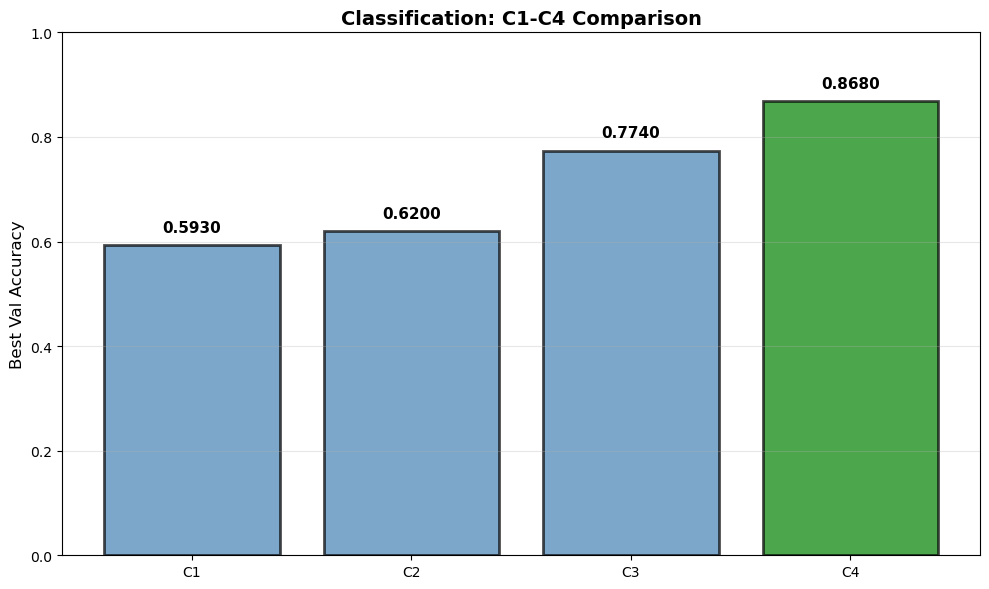

In [12]:
best_exp = max(results_a, key=lambda x: results_a[x]['best_val_acc'])
best_val_acc = results_a[best_exp]['best_val_acc']
print(f'Results: {[(k, f"{v["best_val_acc"]:.4f}") for k, v in results_a.items()]}')
print(f'Best: {best_exp} with {best_val_acc:.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
exps = list(results_a.keys())
accs = [results_a[e]['best_val_acc'] for e in exps]
colors = ['green' if e == best_exp else 'steelblue' for e in exps]
ax.bar(exps, accs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Best Val Accuracy', fontsize=12)
ax.set_title('Classification: C1-C4 Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
for bar, acc in zip(ax.patches, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('./artifacts/figures/classification_compare.png', dpi=100, bbox_inches='tight')
plt.show()

## 12. Test evaluation

Test Acc: 0.8632


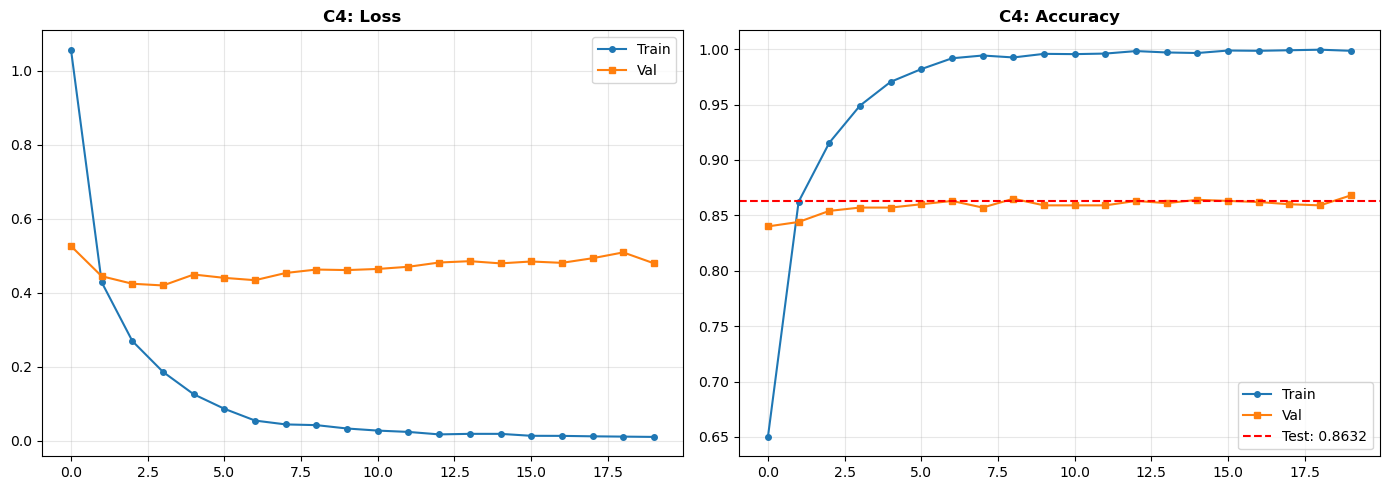

In [13]:
best_model_obj = results_a[best_exp]['model_obj']
best_model_obj.load_state_dict(results_a[best_exp]['model'])
test_loss, test_acc = evaluate(best_model_obj, test_loader, criterion, device)
print(f'Test Acc: {test_acc:.4f}')

best_history = results_a[best_exp]['history']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(best_history['train_loss'], label='Train', marker='o', markersize=4)
axes[0].plot(best_history['val_loss'], label='Val', marker='s', markersize=4)
axes[0].set_title(f'{best_exp}: Loss', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(best_history['train_acc'], label='Train', marker='o', markersize=4)
axes[1].plot(best_history['val_acc'], label='Val', marker='s', markersize=4)
axes[1].axhline(y=test_acc, color='r', linestyle='--', label=f'Test: {test_acc:.4f}')
axes[1].set_title(f'{best_exp}: Accuracy', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./artifacts/figures/classification_curves_best.png', dpi=100, bbox_inches='tight')
plt.show()

## 13-16. Segmentation Part B

## 15. Segmentation Part B: OxfordIIITPet dataset

**Foreground definition**: In OxfordIIITPet, mask values:
- `mask = 0`: background
- `mask > 0`: pet region + boundary pixels

We define **foreground as all pixels where mask > 0** (binary segmentation: pet vs background).
This matches the binarized predictions from DeepLabV3 (argmax output > 0).

In [14]:
pet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mask_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=Image.NEAREST),
    transforms.PILToTensor(),
    transforms.Lambda(lambda t: (t[0] > 0).float())
])

foreground_description = 'OxfordIIITPet foreground: mask > 0 (pet + border region)'
print('Foreground definition:', foreground_description)

pet_dataset = datasets.OxfordIIITPet(
    root=str(data_dir),
    split='trainval',
    target_types='segmentation',
    download=True,
    transform=pet_transform,
    target_transform=mask_transform
)
print(f'OxfordIIITPet: {len(pet_dataset)} samples')

seg_dataset = pet_dataset
seg_loader = DataLoader(seg_dataset, batch_size=4, shuffle=False, num_workers=0)
print(f'Seg dataset created: {len(seg_dataset)} samples')

Foreground definition: OxfordIIITPet foreground: mask > 0 (pet + border region)


100%|██████████| 792M/792M [01:25<00:00, 9.29MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.5MB/s]


OxfordIIITPet: 3680 samples
Seg dataset created: 3680 samples


## 16. V1 vs V2: Segmentation postprocessing

**Foreground definition**: `OxfordIIITPet foreground = argmax(DeepLabV3_output) > 0`
- mask > 0 means: pet region + boundary pixels (any non-background class from COCO/VOC labels)
- Ground truth: same binary definition from dataset masks (transforms.Lambda: t[0] > 0)

**V1 – Baseline (raw prediction)**:
- Postprocessing: raw binary threshold on DeepLabV3 output, no morphological operations
- Formula: `binary_mask = argmax(output['out']) > 0`

**V2 – Morphological cleanup**:
- Postprocessing: binary_closing (3×3) → binary_opening (3×3) → remove small components (<50 pixels)
- Purpose: remove noise, fill small holes, clean boundaries
- Formula: `closing→opening→remove_isolated_blobs`

In [16]:
if seg_dataset:
    seg_model = models.segmentation.deeplabv3_resnet50(weights=models.segmentation.DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1).to(device)
    seg_model.eval()
    print('DeepLabV3 loaded')
    print('Foreground definition: argmax(DeepLabV3_output) > 0 (any non-background COCO/VOC class)')
    
    def postprocess_v1(output):
        # V1: raw prediction baseline
        # Foreground = any non-background class from COCO/VOC labels
        # Definition: argmax(output['out']) > 0
        pred_mask = torch.argmax(output['out'], dim=1)
        return (pred_mask > 0).float()
    
    def postprocess_v2(output):
        # V2: morphological postprocessing for noise reduction and smoothing
        # Steps: binary_closing (fill holes) -> binary_opening (remove noise) -> remove small components
        # Foreground = same as V1: argmax(output['out']) > 0
        pred_mask = torch.argmax(output['out'], dim=1)
        output_np = (pred_mask > 0).cpu().numpy().astype(np.uint8)
        result = []
        for mask in output_np:
            binary_mask = mask.copy()
            # Step 1: binary_closing (3x3 structuring element) - fill small holes
            binary_mask = ndimage.binary_closing(binary_mask, structure=np.ones((3, 3))).astype(np.uint8)
            # Step 2: binary_opening (3x3 structuring element) - remove small noise
            binary_mask = ndimage.binary_opening(binary_mask, structure=np.ones((3, 3))).astype(np.uint8)
            # Step 3: label connected components and remove those < 50 pixels
            labeled, num_features = ndimage.label(binary_mask)
            if num_features > 0:
                sizes = ndimage.sum(binary_mask, labeled, range(num_features + 1))
                for s in range(1, num_features + 1):
                    if sizes[s] < 50:
                        binary_mask[labeled == s] = 0
            result.append(binary_mask)
        return torch.tensor(np.array(result), device=device).float()
    
    v1_pred, v2_pred = [], []
    with torch.no_grad():
        for idx in range(min(10, len(seg_dataset))):
            img, gt_mask = seg_dataset[idx]
            output = seg_model(img.unsqueeze(0).to(device))
            v1_pred.append((img, gt_mask, postprocess_v1(output).squeeze().cpu()))
            v2_pred.append((img, gt_mask, postprocess_v2(output).squeeze().cpu()))
    print(f'Predictions: V1={len(v1_pred)}, V2={len(v2_pred)}')

DeepLabV3 loaded
Foreground definition: argmax(DeepLabV3_output) > 0 (any non-background COCO/VOC class)
Predictions: V1=10, V2=10


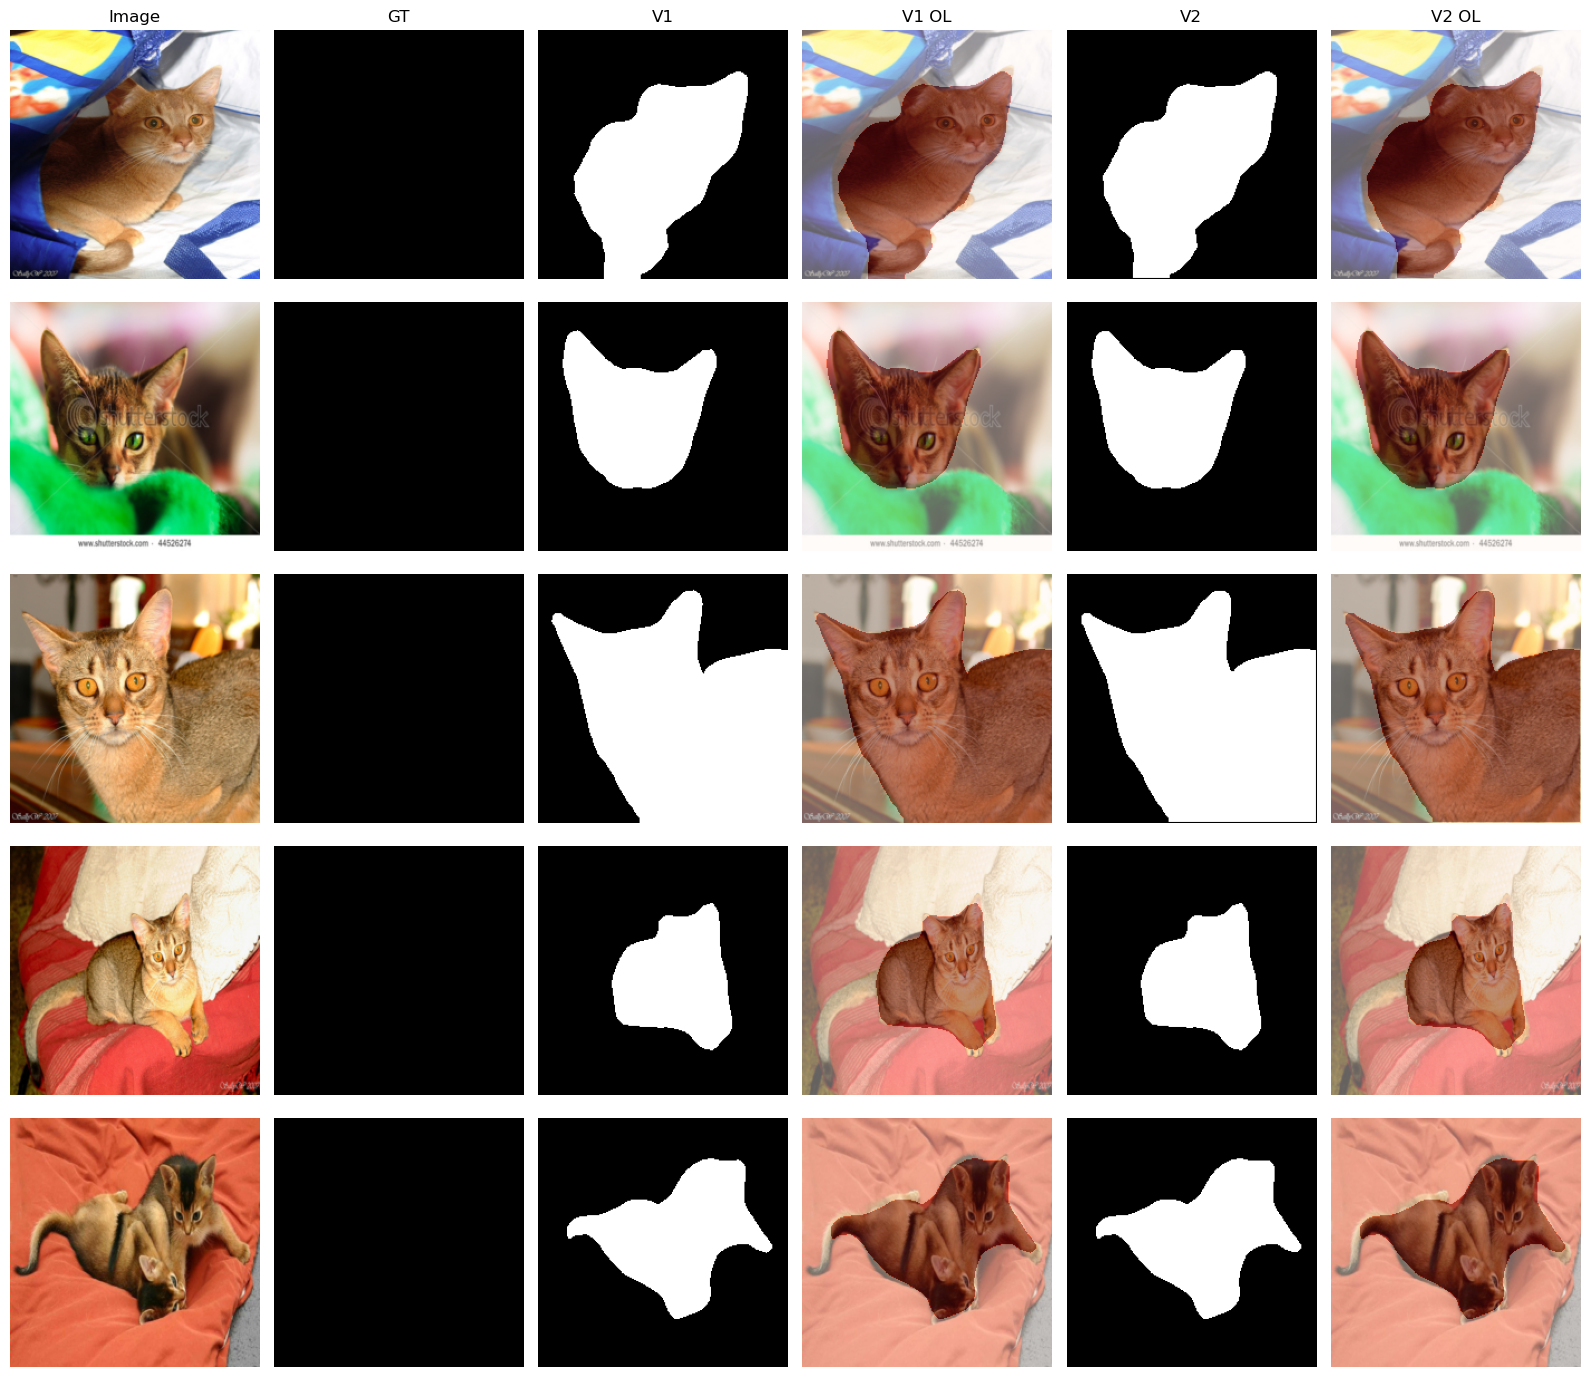

In [17]:
if v1_pred and v2_pred:
    fig, axes = plt.subplots(5, 6, figsize=(16, 14))
    mean_denorm = torch.tensor([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std_denorm = torch.tensor([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    
    for row in range(5):
        img, gt, v1 = v1_pred[row]
        _, _, v2 = v2_pred[row]
        img_denorm = torch.clamp(img * std_denorm + mean_denorm, 0, 1)
        
        axes[row, 0].imshow(img_denorm.permute(1, 2, 0).numpy())
        axes[row, 0].set_title('Image' if row == 0 else '')
        axes[row, 0].axis('off')
        
        axes[row, 1].imshow(gt.numpy(), cmap='gray')
        axes[row, 1].set_title('GT' if row == 0 else '')
        axes[row, 1].axis('off')
        
        axes[row, 2].imshow((v1 > 0).numpy(), cmap='gray')
        axes[row, 2].set_title('V1' if row == 0 else '')
        axes[row, 2].axis('off')
        
        axes[row, 3].imshow(img_denorm.permute(1, 2, 0).numpy())
        axes[row, 3].imshow((v1 > 0).numpy(), cmap='Reds', alpha=0.4)
        axes[row, 3].set_title('V1 OL' if row == 0 else '')
        axes[row, 3].axis('off')
        
        axes[row, 4].imshow((v2 > 0).numpy(), cmap='gray')
        axes[row, 4].set_title('V2' if row == 0 else '')
        axes[row, 4].axis('off')
        
        axes[row, 5].imshow(img_denorm.permute(1, 2, 0).numpy())
        axes[row, 5].imshow((v2 > 0).numpy(), cmap='Reds', alpha=0.4)
        axes[row, 5].set_title('V2 OL' if row == 0 else '')
        axes[row, 5].axis('off')
    
    plt.tight_layout()
    plt.savefig('./artifacts/figures/segmentation_examples.png', dpi=100, bbox_inches='tight')
    plt.show()

## 17-18. Metrics and export

In [18]:
def calc_iou(pred, gt):
    pred, gt = pred.float(), gt.float()
    inter = (pred * gt).sum()
    union = pred.sum() + gt.sum() - inter
    return (inter / union).item() if union > 0 else 0.0

def calc_prec(pred, gt):
    pred, gt = pred.float(), gt.float()
    tp = (pred * gt).sum()
    pp = pred.sum()
    return (tp / pp).item() if pp > 0 else 0.0

def calc_rec(pred, gt):
    pred, gt = pred.float(), gt.float()
    tp = (pred * gt).sum()
    ap = gt.sum()
    return (tp / ap).item() if ap > 0 else 0.0

if v1_pred and v2_pred:
    v1_metrics = {'iou': [], 'prec': [], 'rec': []}
    v2_metrics = {'iou': [], 'prec': [], 'rec': []}
    
    for i in range(len(v1_pred)):
        _, gt, v1 = v1_pred[i]
        _, _, v2 = v2_pred[i]
        v1_bin = (v1 > 0).float()
        v2_bin = (v2 > 0).float()
        v1_metrics['iou'].append(calc_iou(v1_bin, gt))
        v1_metrics['prec'].append(calc_prec(v1_bin, gt))
        v1_metrics['rec'].append(calc_rec(v1_bin, gt))
        v2_metrics['iou'].append(calc_iou(v2_bin, gt))
        v2_metrics['prec'].append(calc_prec(v2_bin, gt))
        v2_metrics['rec'].append(calc_rec(v2_bin, gt))
    
    mean_v1 = {k: np.mean(v) for k, v in v1_metrics.items()}
    mean_v2 = {k: np.mean(v) for k, v in v2_metrics.items()}
    
    print(f'V1: IoU={mean_v1["iou"]:.4f}, Prec={mean_v1["prec"]:.4f}, Rec={mean_v1["rec"]:.4f}')
    print(f'V2: IoU={mean_v2["iou"]:.4f}, Prec={mean_v2["prec"]:.4f}, Rec={mean_v2["rec"]:.4f}')

V1: IoU=0.4357, Prec=1.0000, Rec=0.4357
V2: IoU=0.4320, Prec=1.0000, Rec=0.4320


Artifacts saved: best_classifier.pt, best_classifier_config.json, runs.csv


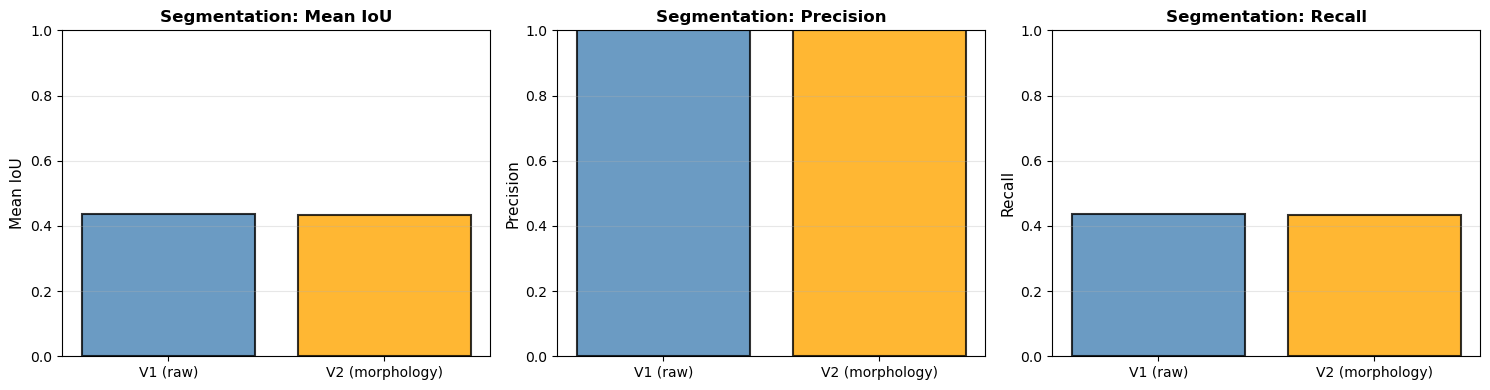

In [19]:
# Save artifacts
torch.save(results_a[best_exp]['model'], './artifacts/best_classifier.pt')

# Detailed architecture descriptions for each experiment
arch_configs = {
    'C1': {
        'architecture': 'SimpleCNN (from scratch)',
        'architecture_details': 'Conv2d(3,32,3,p=1)->ReLU->MaxPool2d(2), Conv2d(32,64,3,p=1)->ReLU->MaxPool2d(2), Conv2d(64,128,3,p=1)->ReLU->MaxPool2d(2), then FC(128*12*12->256)->ReLU->Dropout(0.5)->FC(256->10)',
        'trainable_params': 'all from scratch',
        'input_size': '96x96',
        'preprocessing': 'Resize(96), ToTensor, Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])',
        'train_transform': 'basic_transform (no augmentation)',
        'augmentation': False
    },
    'C2': {
        'architecture': 'SimpleCNN (from scratch)',
        'architecture_details': 'Conv2d(3,32,3,p=1)->ReLU->MaxPool2d(2), Conv2d(32,64,3,p=1)->ReLU->MaxPool2d(2), Conv2d(64,128,3,p=1)->ReLU->MaxPool2d(2), then FC(128*12*12->256)->ReLU->Dropout(0.5)->FC(256->10)',
        'trainable_params': 'all from scratch',
        'input_size': '96x96',
        'preprocessing': 'Resize(96), ToTensor, Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])',
        'train_transform': 'augmented_transform: RandomResizedCrop(0.8-1.0), RandomHFlip(p=0.5), RandomRotation(15°), ColorJitter(0.2)',
        'augmentation': True
    },
    'C3': {
        'architecture': 'ResNet18 (pretrained ImageNet)',
        'architecture_details': 'Backbone frozen, only classification head trainable. Output: 512->10 linear layer',
        'trainable_params': 'only fc layer (head): 512->10',
        'input_size': '96x96',
        'preprocessing': 'Resize(96), ToTensor, Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])',
        'train_transform': 'basic_transform (no augmentation)',
        'augmentation': False
    },
    'C4': {
        'architecture': 'ResNet18 (pretrained ImageNet)',
        'architecture_details': 'Partial fine-tune: layer1,2,3 frozen; layer4 and fc trainable',
        'trainable_params': 'layer4 + fc: (512->10 linear layer)',
        'input_size': '96x96',
        'preprocessing': 'Resize(96), ToTensor, Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])',
        'train_transform': 'basic_transform (no augmentation)',
        'augmentation': False
    }
}

config = {
    'dataset': 'STL-10',
    'classes': 10,
    'num_train_samples': len(train_split),
    'num_val_samples': len(val_split),
    'num_test_samples': len(test_dataset),
    'experiment_id': best_exp,
    **arch_configs[best_exp],
    'optimizer': 'SGD',
    'momentum': 0.9,
    'learning_rate': 0.01 if best_exp in ['C1', 'C2', 'C3'] else 0.001,
    'epochs_trained': NUM_EPOCHS,
    'batch_size': BATCH_SIZE,
    'seed': SEED,
    'train_val_split': '80/20',
    'best_val_accuracy': float(best_val_acc),
    'test_accuracy': float(test_acc),
    'notes': 'Best experiment selected by validation accuracy. Test accuracy evaluated once on held-out test set.'
}
with open('./artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=4)

# Create runs.csv with detailed experiment descriptions
runs_data = []
for exp_id in ['C1', 'C2', 'C3', 'C4']:
    cfg = arch_configs[exp_id]
    runs_data.append({
        'experiment_id': exp_id,
        'task': 'classification',
        'dataset': 'STL-10',
        'seed': SEED,
        'architecture': cfg['architecture'],
        'model_summary': {
            'C1': 'SimpleCNN (basic, no aug)',
            'C2': 'SimpleCNN (with augmentation)',
            'C3': 'ResNet18 (frozen backbone, trainable head)',
            'C4': 'ResNet18 (frozen layer1-3, trainable layer4+head)'
        }[exp_id],
        'trainable_params': cfg['trainable_params'],
        'preprocessing': cfg['preprocessing'],
        'augmentation': 'Yes' if cfg['augmentation'] else 'No',
        'optimizer': 'SGD',
        'momentum': '0.9',
        'lr': '0.01' if exp_id in ['C1', 'C2', 'C3'] else '0.001',
        'epochs_trained': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'best_val_accuracy': f'{results_a[exp_id]["best_val_acc"]:.6f}',
        'test_accuracy': f'{test_acc:.6f}' if exp_id == best_exp else '',
        'precision': '',
        'recall': '',
        'mean_iou': '',
        'notes': 'Best' if exp_id == best_exp else ''
    })

if seg_dataset:
    runs_data.extend([
        {
            'experiment_id': 'V1',
            'task': 'segmentation',
            'dataset': 'OxfordIIITPet',
            'seed': SEED,
            'architecture': 'DeepLabV3-ResNet50 (pretrained COCO+VOC)',
            'model_summary': 'DeepLabV3-ResNet50 inference',
            'trainable_params': 'N/A (pretrained, inference only)',
            'preprocessing': 'Resize(224,224), ToTensor, Normalize(ImageNet)',
            'augmentation': 'No',
            'optimizer': 'N/A',
            'momentum': 'N/A',
            'lr': 'N/A',
            'epochs_trained': 0,
            'batch_size': '1 (inference)',
            'best_val_accuracy': '',
            'test_accuracy': '',
            'precision': f'{mean_v1["prec"]:.6f}',
            'recall': f'{mean_v1["rec"]:.6f}',
            'mean_iou': f'{mean_v1["iou"]:.6f}',
            'notes': 'V1-Baseline: Foreground=argmax(output)>0 (pet+border region). Postprocess: raw binary mask from model, no morphology. Metrics: IoU, precision, recall on 10 test samples.'
        },
        {
            'experiment_id': 'V2',
            'task': 'segmentation',
            'dataset': 'OxfordIIITPet',
            'seed': SEED,
            'architecture': 'DeepLabV3-ResNet50 (pretrained COCO+VOC)',
            'model_summary': 'DeepLabV3-ResNet50 inference',
            'trainable_params': 'N/A (pretrained, inference only)',
            'preprocessing': 'Resize(224,224), ToTensor, Normalize(ImageNet)',
            'augmentation': 'No',
            'optimizer': 'N/A',
            'momentum': 'N/A',
            'lr': 'N/A',
            'epochs_trained': 0,
            'batch_size': '1 (inference)',
            'best_val_accuracy': '',
            'test_accuracy': '',
            'precision': f'{mean_v2["prec"]:.6f}',
            'recall': f'{mean_v2["rec"]:.6f}',
            'mean_iou': f'{mean_v2["iou"]:.6f}',
            'notes': 'V2-Morphology: Foreground=argmax(output)>0 (pet+border region). Postprocess: binary_closing(3x3) + binary_opening(3x3) + remove_small_components(<50px). Metrics: IoU, precision, recall on 10 test samples.'
        }
    ])

pd.DataFrame(runs_data).to_csv('./artifacts/runs.csv', index=False)
print('Artifacts saved: best_classifier.pt, best_classifier_config.json, runs.csv')

if seg_dataset:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for idx, (ax, metric) in enumerate(zip(axes, ['Mean IoU', 'Precision', 'Recall'])):
        keys = ['iou', 'prec', 'rec']
        v1_val = mean_v1[keys[idx]]
        v2_val = mean_v2[keys[idx]]
        ax.bar(['V1 (raw)', 'V2 (morphology)'], [v1_val, v2_val], color=['steelblue', 'orange'], alpha=0.8, edgecolor='black', linewidth=1.5)
        ax.set_title(f'Segmentation: {metric}', fontweight='bold', fontsize=12)
        ax.set_ylim([0, 1])
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylabel(metric, fontsize=11)
    plt.tight_layout()
    plt.savefig('./artifacts/figures/segmentation_metrics.png', dpi=100, bbox_inches='tight')
    plt.show()

## Summary

In [20]:
print('='*60)
print('HW10-11 SUMMARY')
print('='*60)
print('\nPart A: Classification')
for exp, data in results_a.items():
    print(f'  {exp}: {data["best_val_acc"]:.4f}')
print(f'  Test ({best_exp}): {test_acc:.4f}')
if seg_dataset:
    print('\nPart B: Segmentation')
    print(f'  V1 IoU: {mean_v1["iou"]:.4f}')
    print(f'  V2 IoU: {mean_v2["iou"]:.4f}')
print('\nArtifacts saved to ./artifacts/')
print('='*60)

HW10-11 SUMMARY

Part A: Classification
  C1: 0.5930
  C2: 0.6200
  C3: 0.7740
  C4: 0.8680
  Test (C4): 0.8632

Part B: Segmentation
  V1 IoU: 0.4357
  V2 IoU: 0.4320

Artifacts saved to ./artifacts/
